# EDA — Multimodal Price Prediction

Quick, CPU-only, **CSV-only** exploratory pass over the raw catalog data — no
images and no embeddings are loaded in this notebook (that happens in the
pipeline itself; see `src/` and `config/config.yaml`). Goal here is just to
understand the target distribution, the text fields, and the parsed
quantity/unit fields well enough to justify the feature-engineering and
target-transform choices described in `docs/ARCHITECTURE.md`.


In [1]:
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 120)

# Local copy of the raw training CSV, laid out as described in
# ../data/README.md (data_root/dataset/train.csv). Raw data is not
# committed to this repository -- update this path if running elsewhere.
DATA = "../data/dataset/train.csv"

df = pd.read_csv(DATA)
print(f"shape: {df.shape}")
df.dtypes

shape: (75000, 4)


sample_id            int64
catalog_content     object
image_link          object
price              float64
dtype: object

In [2]:
print("missing values per column:")
print(df.isnull().sum())
print()
df.head(3)

missing values per column:
sample_id          0
catalog_content    0
image_link         0
price              0
dtype: int64



,sample_id,catalog_content,image_link,price
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, 12 Ounce (Pack of 6)\nValue: 72.0\nUnit: Fl Oz\n",https://m.media-amazon.com/images/I/51mo8htwTHL.jpg,4.89
1,198967,"Item Name: Salerno Cookies, The Original Butter Cookies, 8 Ounce (Pack of 4)\nBullet Point 1: Original Butter Cookie...",https://m.media-amazon.com/images/I/71YtriIHAAL.jpg,13.12
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy Chicken with Rice, 1.9 Ounce (Pack of 6)\nBullet Point 1: Loaded with...",https://m.media-amazon.com/images/I/51+PFEe-w-L.jpg,1.97


In [3]:
df["price"].describe()

count    75000.000000
mean        23.647654
std         33.376932
min          0.130000
25%          6.795000
50%         14.000000
75%         28.625000
max       2796.000000
Name: price, dtype: float64

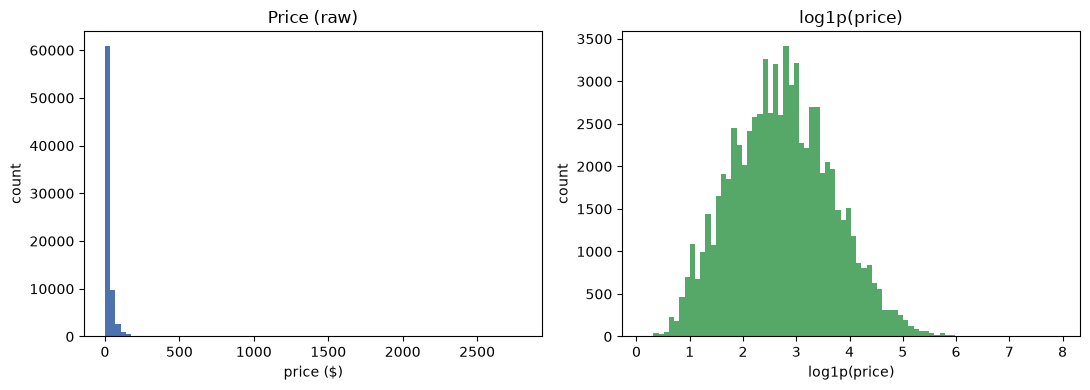

In [4]:
log_price = np.log1p(df["price"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["price"], bins=80, color="#4C72B0")
axes[0].set_title("Price (raw)")
axes[0].set_xlabel("price ($)")
axes[0].set_ylabel("count")

axes[1].hist(log_price, bins=80, color="#55A868")
axes[1].set_title("log1p(price)")
axes[1].set_xlabel("log1p(price)")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

distinct raw unit strings:        99
distinct normalized unit strings: 70
rows with unit == 'none' (missing-value sentinel): 940


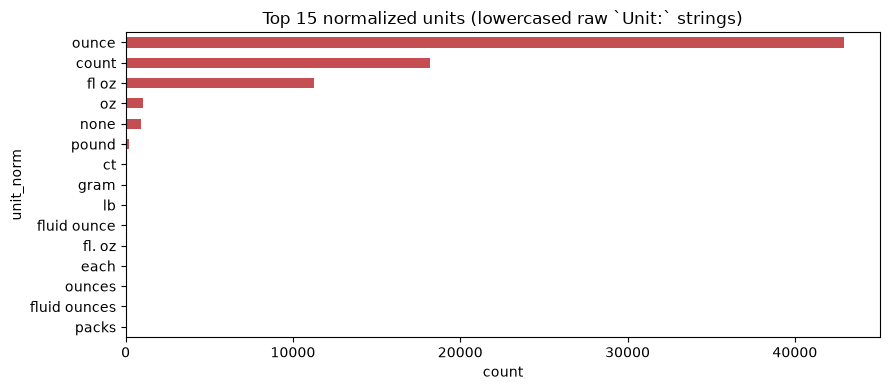

unit_norm
ounce           42942
count           18209
fl oz           11257
oz               1064
none              940
pound             202
ct                 49
gram               39
lb                 34
fluid ounce        33
fl. oz             22
each               21
ounces             20
fluid ounces       14
packs              12
Name: count, dtype: int64

In [5]:
def extract_field(text, field):
    """Pull the rest of a `Field: ...` line out of catalog_content."""
    if not isinstance(text, str):
        return None
    m = re.search(rf"{field}:\s*(.*)", text)
    return m.group(1).strip() if m else None


df["unit_raw"] = df["catalog_content"].apply(lambda t: extract_field(t, "Unit"))
df["unit_norm"] = df["unit_raw"].str.strip().str.rstrip(".").str.lower()

print(f"distinct raw unit strings:        {df['unit_raw'].nunique()}")
print(f"distinct normalized unit strings: {df['unit_norm'].nunique()}")
print(f"rows with unit == 'none' (missing-value sentinel): {(df['unit_norm'] == 'none').sum()}")

top_units = df["unit_norm"].value_counts().head(15)

plt.figure(figsize=(9, 4))
top_units.iloc[::-1].plot(kind="barh", color="#C44E52")
plt.xlabel("count")
plt.title("Top 15 normalized units (lowercased raw `Unit:` strings)")
plt.tight_layout()
plt.show()

top_units

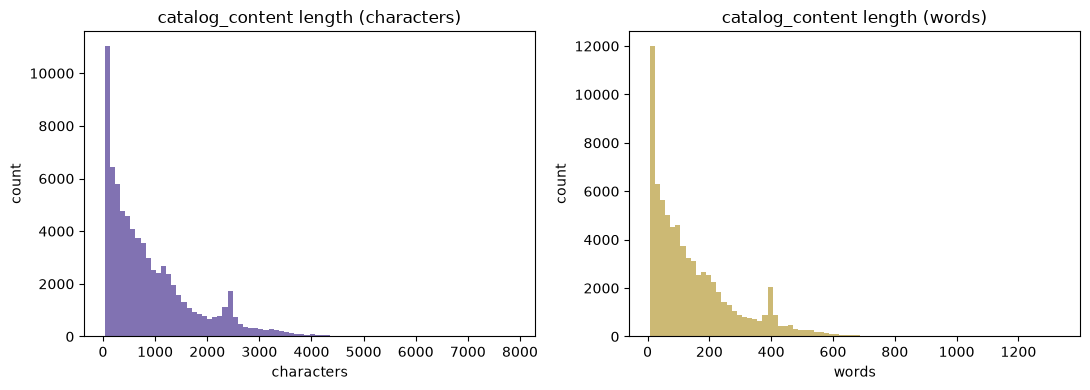

count    75000.000000
mean       908.886547
std        852.896151
min         32.000000
25%        251.000000
50%        643.000000
75%       1280.000000
max       7894.000000
Name: catalog_content, dtype: float64

In [6]:
char_len = df["catalog_content"].str.len()
word_count = df["catalog_content"].str.split().apply(len)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(char_len, bins=80, color="#8172B2")
axes[0].set_title("catalog_content length (characters)")
axes[0].set_xlabel("characters")
axes[0].set_ylabel("count")

axes[1].hist(word_count, bins=80, color="#CCB974")
axes[1].set_title("catalog_content length (words)")
axes[1].set_xlabel("words")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

char_len.describe()

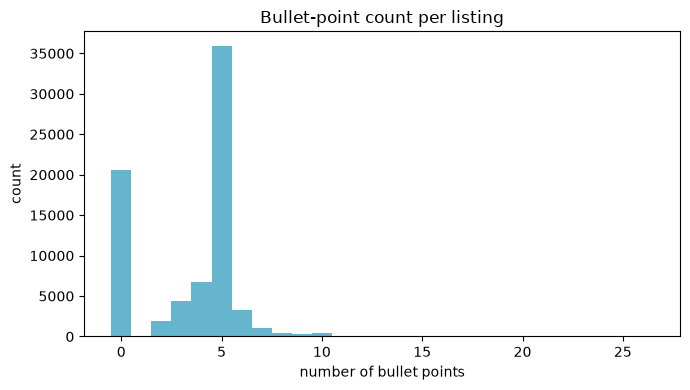

count    75000.000000
mean         3.485387
std          2.343807
min          0.000000
25%          0.000000
50%          5.000000
75%          5.000000
max         26.000000
Name: catalog_content, dtype: float64

In [7]:
bullet_count = df["catalog_content"].apply(lambda t: len(re.findall(r"Bullet Point \d+:", t)))

plt.figure(figsize=(7, 4))
plt.hist(bullet_count, bins=range(0, bullet_count.max() + 2), color="#64B5CD", align="left")
plt.xlabel("number of bullet points")
plt.ylabel("count")
plt.title("Bullet-point count per listing")
plt.tight_layout()
plt.show()

bullet_count.describe()

rows with a parseable numeric Value: 74040 / 75000


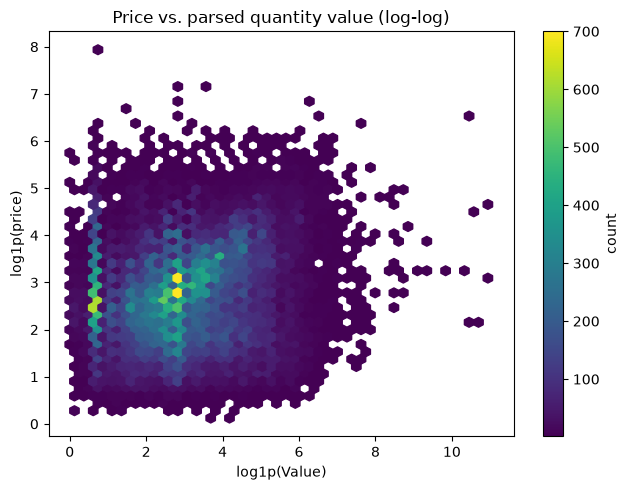

np.float64(0.14920600099530937)

In [8]:
value = pd.to_numeric(df["catalog_content"].apply(lambda t: extract_field(t, "Value")), errors="coerce")
log_value = np.log1p(value)

mask = log_value.notna() & df["price"].notna()
print(f"rows with a parseable numeric Value: {mask.sum()} / {len(df)}")

plt.figure(figsize=(6.5, 5))
hb = plt.hexbin(log_value[mask], log_price[mask], gridsize=45, cmap="viridis", mincnt=1)
plt.xlabel("log1p(Value)")
plt.ylabel("log1p(price)")
plt.title("Price vs. parsed quantity value (log-log)")
plt.colorbar(hb, label="count")
plt.tight_layout()
plt.show()

log_value.corr(log_price)

## Takeaways

- **No missing values** in any of the four raw columns (`sample_id`, `catalog_content`, `image_link`, `price`) — the dataset is complete at the row level. Noise shows up *within* fields instead (below), not as nulls.
- **Price is heavy-tailed**, as expected going in: median $14.00, mean $23.65 (pulled up by the tail, ~1.7x the median), min $0.13, max $2,796. This is the main justification for modeling `log(price)` and for using SMAPE/RMSLE as headline metrics rather than raw MAE/R².
- **Unit strings are genuinely messy.** 99 distinct raw `Unit:` strings collapse to only 70 after simple lowercase + strip normalization — nowhere near enough on its own. The pipeline's unit parser needs an explicit alias table (`ounce` / `oz` / `ounces` / `fl oz` / `fluid ounce` / `fluid ounces` / ... all mean approximately the same thing), not just casing normalization. A literal `"none"` sentinel string appears in 940 rows (1.25%) — a missing unit disguised as a value, not a null.
- **Bullet points are unevenly present.** Mean 3.49 bullet points per listing, but the 25th percentile is exactly 0 — at least a quarter of listings have no bullet points at all, relying on `Item Name` plus the `Value`/`Unit` fields alone. Text-derived features need to degrade gracefully for these rows.
- **`catalog_content` length varies widely** (32–7,894 characters, median 643), which is the motivation for including raw character/word/bullet counts as tabular features alongside the MiniLM embedding — the embedding alone may not fully capture "how much information is here."
- **Quantity value is only weakly predictive of price on its own.** `log1p(Value)` vs. `log1p(price)` has a Pearson correlation of ≈0.15 across the 74,040 rows (98.7%) with a parseable `Value`. Bigger pack sizes are not simply more expensive in a clean log-log sense — `Value`/`Unit` only become useful in combination with the brand/category signal carried by the rest of the text, which is the whole motivation for fusing them with the MiniLM embedding rather than using either alone.
